# 10k-rag — Hierarchical RAG over MAG7 10-K filings

An interactive demo of the chunking + retrieval + answer pipeline.

The corpus is **35 SEC 10-K filings** — Microsoft, Apple, Alphabet, Amazon, Meta, Nvidia, and Tesla, fiscal years 2021 through 2025.

The deliverable for the AI Engineering Cohort 2026 Week 7 assignment is **hierarchical chunking**: children (paragraphs and tables) get embedded for similarity search, but each child maps to one parent (the containing Item or sub-section) — and at retrieval time the system expands matched children up to their parents before sending context to the answering LLM.

This notebook walks through:

1. **The hierarchy** — what parents, children, and the one-hop expansion actually look like in our data
2. **Chunk-size sanity check** — the Pareto distribution that signals well-shaped chunks
3. **Retrieve-only walkthrough** — what the vector index returns before the LLM gets involved
4. **End-to-end with citations** — the full pipeline producing a sourced answer
5. **A grid of canned queries** showing cross-company and longitudinal comparisons
6. **Graceful failure** — an out-of-scope query the system declines to answer

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src.config_loader import load_config
from src.rag import RAGSystem

cfg = load_config()
system = RAGSystem(cfg=cfg, llm_backend="auto")
print(f"Backend: {system.llm_backend}")
print(f"Collection: {system.collection.count():,} children")
print(f"Parents loaded: {len(system.parents):,}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Backend: claude_cli
Collection: 22,632 children
Parents loaded: 4,583


## 1 · The hierarchy in concrete form

We pick one filing — Microsoft FY2024 — and ask: how many parents does it have, how many children, what does one parent + its children actually look like?

Recall the contract:

- **Parent** = the most-specific containing section (sub-heading region if available; else the whole Item)
- **Child** = a paragraph (default 80–1200 chars) or a single table
- **One hop**: each child stores `parent_id`. Retrieval matches on children; we look up parents once.

In [2]:
import pandas as pd
from collections import Counter

TICKER, FY = "MSFT", "FY2024"

msft_parents = [p for p in system.parents.values()
                if p["metadata"]["ticker"] == TICKER
                and p["metadata"]["fy_label"] == FY]
msft_children = [c for c in (json.loads(L) for L in open(REPO / "data/chunks/children.jsonl"))
                 if c["metadata"]["ticker"] == TICKER
                 and c["metadata"]["fy_label"] == FY]

by_item = Counter(p["metadata"]["item"] for p in msft_parents)
child_counts = Counter(c["parent_id"] for c in msft_children)

summary = pd.DataFrame({
    "Item": list(by_item.keys()),
    "#parents (sub-sections or Item-level)": [by_item[i] for i in by_item],
    "#children": [
        sum(child_counts[p["parent_id"]] for p in msft_parents
            if p["metadata"]["item"] == it)
        for it in by_item
    ],
}).sort_values("Item")
summary

,Item,#parents (sub-sections or Item-level),#children
0,Item 1,25,157
1,Item 1A,10,103
2,Item 1C,1,14
3,Item 2,1,4
4,Item 3,1,1
5,Item 5,1,8
6,Item 7,15,77
7,Item 7A,16,136
8,Item 8,18,177
9,Item 9A,3,9


In [3]:
# Show one parent + its first three children, verbatim
from textwrap import shorten

sample_parent = next(p for p in msft_parents
                     if p["metadata"]["item"] == "Item 1A"
                     and p["metadata"].get("sub_heading"))

print("PARENT")
print("  parent_id:    ", sample_parent["parent_id"])
print("  item:         ", sample_parent["metadata"]["item"])
print("  sub_heading:  ", sample_parent["metadata"]["sub_heading"])
print("  text length:  ", f"{len(sample_parent['text']):,} chars")
print("  text head:    ", shorten(sample_parent["text"], 220))
print()

kids = [c for c in msft_children if c["parent_id"] == sample_parent["parent_id"]][:3]
print(f"FIRST 3 CHILDREN (of {child_counts[sample_parent['parent_id']]} total)")
for c in kids:
    print("  -", c["chunk_id"], f"[{c['chunk_type']}, {len(c['text']):,} chars]")
    print("    ", shorten(c["text"], 180))

PARENT
  parent_id:     MSFT-FY2024-1A-business-model-competition
  item:          Item 1A
  sub_heading:   Business model competition
  text length:   10,400 chars
  text head:     Companies compete with us based on a growing variety of business models. A material part of our business involves cloud-based services available across the spectrum of computing devices. Our competitors continue to [...]

FIRST 3 CHILDREN (of 20 total)
  - MSFT-FY2024-1A-business-model-competition-p1 [prose, 446 chars]
     Companies compete with us based on a growing variety of business models. A material part of our business involves cloud-based services available across the spectrum of [...]
  - MSFT-FY2024-1A-business-model-competition-p2 [prose, 623 chars]
     We are investing in artificial intelligence (“AI”) across the entire company and infusing generative AI capabilities into our consumer and commercial offerings. We expect AI [...]
  - MSFT-FY2024-1A-business-model-competition-p3 [prose, 515 char

## 2 · Chunk-size sanity check (the Pareto trick)

From Gaurav's Week 7 day-2 lecture: a healthy chunker produces a **Pareto-shaped** size distribution — most chunks are short (single paragraphs), a long tail is longer (multi-paragraph notes). A flat distribution (all chunks ~ same size) signals you're chopping by character count and not respecting natural delimiters.

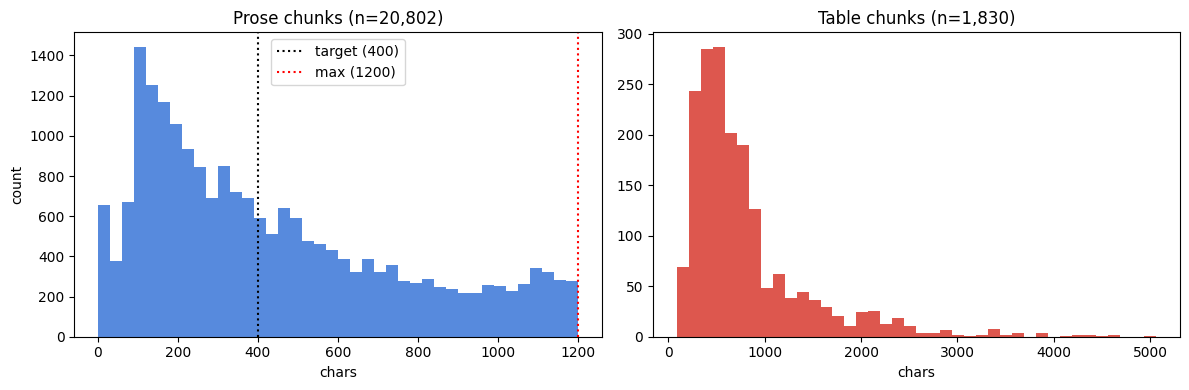

Prose median: 349 chars
Prose 99th %: 1,178 chars
Table median: 616 chars


In [4]:
import matplotlib.pyplot as plt

all_children = [json.loads(L) for L in open(REPO / "data/chunks/children.jsonl")]
prose_sizes = [len(c["text"]) for c in all_children if c["chunk_type"] == "prose"]
table_sizes = [len(c["text"]) for c in all_children if c["chunk_type"] == "table"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prose_sizes, bins=40, color="#3a76d8", alpha=0.85)
axes[0].set_title(f"Prose chunks (n={len(prose_sizes):,})")
axes[0].set_xlabel("chars"); axes[0].set_ylabel("count")
axes[0].axvline(cfg.chunking.child_target_chars, color="k", linestyle=":",
                label=f"target ({cfg.chunking.child_target_chars})")
axes[0].axvline(cfg.chunking.child_max_chars, color="r", linestyle=":",
                label=f"max ({cfg.chunking.child_max_chars})")
axes[0].legend()
axes[1].hist(table_sizes, bins=40, color="#d8392f", alpha=0.85)
axes[1].set_title(f"Table chunks (n={len(table_sizes):,})")
axes[1].set_xlabel("chars")
plt.tight_layout(); plt.show()

print(f"Prose median: {sorted(prose_sizes)[len(prose_sizes)//2]:,} chars")
print(f"Prose 99th %: {sorted(prose_sizes)[int(len(prose_sizes)*0.99)]:,} chars")
print(f"Table median: {sorted(table_sizes)[len(table_sizes)//2]:,} chars")

## 3 · Retrieve-only — what the vector index returns

Before the LLM gets involved, the system embeds the query, runs HNSW similarity search over children, and ranks them. Children are precise but small — they tell us *where* to look but not enough to *answer*.

In [5]:
query = "How has Microsoft framed AI as a competitive risk?"

children = system.retrieve(query, top_k=8)
rows = []
for c in children:
    md = c.metadata
    rows.append({
        "sim": round(c.similarity, 3),
        "ticker": md.get("ticker"),
        "fy": md.get("fy_label"),
        "item": md.get("item"),
        "sub_heading": md.get("sub_heading") or "(item-level)",
        "chunk_chars": len(c.text),
        "head": c.text[:90].strip(),
    })
pd.DataFrame(rows)

,sim,ticker,fy,item,sub_heading,chunk_chars,head
0,0.578,MSFT,FY2025,Item 1A,Other digital safety abuses,1086,Ineffective or inadequate AI development or de...
1,0.575,MSFT,FY2023,Item 7,(item-level),526,OVERVIEW Microsoft is a technology company who...
2,0.571,MSFT,FY2022,Item 1A,Other digital safety abuses,1165,Issues in the development and use of AI may re...
3,0.568,MSFT,FY2023,Item 1A,Other digital safety abuses,1177,Issues in the development and use of AI may re...
4,0.565,MSFT,FY2024,Item 1A,Other digital safety abuses,1183,Issues in the development and use of AI may re...
5,0.549,MSFT,FY2024,Item 1,Search and News Advertising,187,Microsoft AI – focuses on delivering online ex...
6,0.537,MSFT,FY2025,Item 1,Windows and Devices,156,• Growth of the AI PC category. Attachment of ...
7,0.532,GOOGL,FY2022,Item 1A,Risks Specific to our Company,485,"In addition, new and evolving products and ser..."


In [6]:
# Now the parent-expansion step — collapse 8 children to ≤4 unique parents
parents = system.expand_parents(children, max_unique=4)
rows = []
for p in parents:
    md = p.metadata
    rows.append({
        "best_sim": round(p.best_similarity, 3),
        "matched_children": len(p.matched_children),
        "ticker": md.get("ticker"),
        "fy": md.get("fy_label"),
        "item": md.get("item"),
        "sub_heading": md.get("sub_heading") or "(item-level)",
        "parent_chars": len(p.text),
    })
pd.DataFrame(rows)

,best_sim,matched_children,ticker,fy,item,sub_heading,parent_chars
0,0.578,1,MSFT,FY2025,Item 1A,Other digital safety abuses,11579
1,0.575,1,MSFT,FY2023,Item 7,(item-level),3393
2,0.571,1,MSFT,FY2022,Item 1A,Other digital safety abuses,11917
3,0.568,1,MSFT,FY2023,Item 1A,Other digital safety abuses,11266


## 4 · End-to-end with citations

Same query, now run all the way through. The LLM receives the **parents** (~4-12 KB of contiguous narrative each), not the raw retrieved paragraph children. That gives it enough surrounding context to answer accurately and cite sources.

In [7]:
from IPython.display import Markdown, display

r = system.ask(query, top_k=8, max_unique=4)
display(Markdown(f"### Q: {r.query}\n\n{r.answer}"))

print("\nSources used:")
for i, p in enumerate(r.parents, 1):
    md = p.metadata
    print(f"  [{i}] {md['ticker']} {md['fy_label']} {md['item']}"
          f" → {md.get('sub_heading') or '(item-level)'}")
    print(f"      {md['edgar_url']}")

### Q: How has Microsoft framed AI as a competitive risk?

Microsoft's framing of AI as a competitive risk has evolved across fiscal years, growing more expansive over time.

**FY2022 — Initial framing (narrow, mostly reputational):** Microsoft described AI risks primarily in terms of flawed algorithms, insufficient or biased datasets, and "ineffective or inadequate AI development or deployment practices" that could "impair the acceptance of AI solutions or cause harm to individuals or society." The cited consequences were "competitive harm, regulatory action, legal liability... and brand or reputational harm," with ethical issues flagged around human rights, privacy, and employment (MSFT FY2022 Item 1A).

**FY2023 — Expanded scope:** The risk header itself shifted from "reputational harm or liability" to "**reputational or competitive harm or liability**," and the discussion broadened to include AI developed by "our strategic partner, OpenAI," content that "may be offensive, illegal, or otherwise harmful," the need for "human review of certain outputs," and exposure to "new applications of existing data protection, privacy, intellectual property, and other laws." Risks from "unintended consequences" or "unintended usage or customization by our customers and partners" were added (MSFT FY2023 Item 1A).

**FY2025 — Further expansion:** Microsoft added explicit references to "agentic AI systems that can take actions autonomously," noted that customers "may deploy them in high-risk scenarios or utilize them inappropriately," and emphasized "rising divergence globally" requiring it to "navigate a web of different tensions across geographies." It also tied AI risk directly to competitive position, warning that controversial outcomes could adversely affect "our reputation, **competitive position**, business, financial condition, and results of operations" (MSFT FY2025 Item 1A).

**Operational/competitive angle:** Across FY2023 and FY2025, Microsoft also framed AI as driving competitive pressure on infrastructure — datacenter dependencies on "permitted and buildable land, predictable energy, networking supplies, and servers, including graphics processing units" — with competitors using "some of the same suppliers" for hardware components, which could constrain capacity needed "to support the delivery and continued development of our products and services" (MSFT FY2023 Item 1A; MSFT FY2025 Item 1A).

In short: Microsoft has progressively elevated AI from a mainly reputational/ethical risk (FY2022) to an explicit competitive risk tied to partner dependencies (OpenAI), agentic autonomy, regulatory divergence, and GPU/datacenter supply competition (FY2023 → FY2025).


Sources used:
  [1] MSFT FY2025 Item 1A → Other digital safety abuses
      https://www.sec.gov/Archives/edgar/data/789019/000095017025100235/msft-20250630.htm
  [2] MSFT FY2023 Item 7 → (item-level)
      https://www.sec.gov/Archives/edgar/data/789019/000095017023035122/msft-20230630.htm
  [3] MSFT FY2022 Item 1A → Other digital safety abuses
      https://www.sec.gov/Archives/edgar/data/789019/000156459022026876/msft-10k_20220630.htm
  [4] MSFT FY2023 Item 1A → Other digital safety abuses
      https://www.sec.gov/Archives/edgar/data/789019/000095017023035122/msft-20230630.htm


## 5 · Cross-company and longitudinal queries

These are the question shapes that this corpus enables — and that a single-document RAG (or just asking the LLM directly without retrieval) cannot answer accurately:

In [8]:
queries = [
    "How does each MAG7 company describe their cybersecurity governance under Item 1C?",
    "What did Tesla and Nvidia say about export-control / China-related risks?",
    "Compare Apple's iPhone revenue commentary in MD&A across FY2023, FY2024, and FY2025.",
    "Which MAG7 companies disclosed material legal proceedings related to antitrust?",
]

for q in queries:
    print("\n" + "=" * 78)
    r = system.ask(q, top_k=10, max_unique=5)
    display(Markdown(f"**Q:** {r.query}\n\n{r.answer}"))
    print("Sources:", ", ".join(
        f"{p.metadata['ticker']} {p.metadata['fy_label']} {p.metadata['item']}"
        for p in r.parents
    ))

**Q:** How does each MAG7 company describe their cybersecurity governance under Item 1C?

# Cybersecurity Governance Under Item 1C

The provided excerpts only cover **Microsoft** and **Tesla** — there are no Item 1C excerpts for Apple, Alphabet, Amazon, Meta, or Nvidia.

## Microsoft (MSFT)

Microsoft describes a layered governance structure:

- **Board oversight**: The Board of Directors oversees cybersecurity risk, with reviews scheduled at least quarterly. Presentations are made by senior management including the CISO, EVP of Microsoft Security, and the head of Customer Security and Trust (MSFT FY2024 Item 1C). In FY2025, presenters also include the EVP of Cloud + AI (MSFT FY2025 Item 1C).
- **CISO reporting line**: The CISO leads strategy, engineering, and operations of cybersecurity. In FY2024 the CISO reported to the EVP of Microsoft Security (MSFT FY2024 Item 1C); by FY2025, the CISO reports to the EVP of Cloud + AI (MSFT FY2025 Item 1C).
- **Cybersecurity Governance Council (CGC)**: An executive-level team of Deputy CISOs that approves the enterprise security risk assessment, determines appropriate risk levels and mitigations, reviews NIST CSF alignment, and supports compliance with cybersecurity regulations (MSFT FY2024 Item 1C; MSFT FY2025 Item 1C).
- **Escalation and integration**: An escalation process informs senior management and the Board of significant issues, and cybersecurity is considered in Board discussions on ERM, audits, business continuity, M&A, and brand management (MSFT FY2024 Item 1C; MSFT FY2025 Item 1C).

## Tesla (TSLA)

Tesla's Item 1C excerpts (FY2023, FY2024, FY2025) describe risk management and strategy but do not contain a separate "Governance" subsection in the provided text. The excerpts state that incident responses are "overseen by leaders from our Information Security, Product Security, Compliance and Legal teams regarding matters of cybersecurity" (TSLA FY2023 Item 1C; TSLA FY2024 Item 1C; TSLA FY2025 Item 1C), and that Tesla regularly engages external auditors and consultants and has been certified to ISO/IEC 27001:2013 (TSLA FY2023 Item 1C; TSLA FY2024 Item 1C; TSLA FY2025 Item 1C). Beyond this, the provided excerpts do not describe Tesla's board-level oversight or management committee structure for cybersecurity.

## Other MAG7 Companies

The provided 10-K excerpts do not address cybersecurity governance for Apple, Alphabet, Amazon, Meta, or Nvidia.

Sources: MSFT FY2024 Item 1C, TSLA FY2023 Item 1C, TSLA FY2024 Item 1C, TSLA FY2025 Item 1C, MSFT FY2025 Item 1C



**Q:** What did Tesla and Nvidia say about export-control / China-related risks?

# Tesla

The provided 10-K excerpts do not address Tesla's export-control or China-related risks — no Tesla excerpts were provided.

# NVIDIA

NVIDIA's filings describe an escalating series of U.S. export-control actions targeting its AI/data-center GPUs sold into China and related regions:

**Timeline of restrictions:**
- August 2022: USG announced export restrictions targeting China's semiconductor and supercomputing industries, specifically impacting A100 and H100 products (NVDA FY2026 Item 1A).
- July 2023: Additional licensing requirement for a subset of A100/H100 products to certain Middle East customers (NVDA FY2026 Item 1A).
- October 2023: New licensing requirements for exports to China and Country Groups D:1, D:4, D:5 (including Saudi Arabia, UAE, Vietnam) covering A100, A800, H100, H800, L4, L40, L40S, RTX 4090, GB200 NVL72, and B200 (NVDA FY2024 Item 1A; NVDA FY2026 Item 1A). NVIDIA noted it "ha[d] not received licenses to ship these restricted products to China" (NVDA FY2024 Item 1A).
- April 2025: Licensing required for H20 chips and any circuits matching its memory/interconnect bandwidth, leading to a "$4.5 billion charge in the first quarter of fiscal year 2026 associated with H20 for excess inventory and purchase obligations" (NVDA FY2026 Item 1A).
- August 2025: Limited H20 licenses granted, generating ~$60 million in revenue, with USG officials expressing an expectation of receiving "15% or more of the revenue generated from licensed sales" (NVDA FY2026 Item 1A).
- February 2026: Limited H200 license granted, but shipments require U.S. inspection and a 25% import tariff (NVDA FY2026 Item 1A).

**AI Diffusion IFR:** In January 2025, the USG published the AI Diffusion IFR, which would have imposed worldwide licensing on data-center products (H200, GB200, GB300) and divided countries into three tiers, with most in "Tier 2" (NVDA FY2026 Item 1A; NVDA FY2025 Item 1A). In May 2025, the USG announced it would rescind the IFR and replace it; the October 2025 Senate-passed "GAIN AI Act" could further constrain the administration's ability to adapt the rules (NVDA FY2026 Item 1A).

**Competitive and market impact:**
- As of end of FY2026, NVIDIA was "effectively foreclosed from competing in China's data center computing/compute market," helping competitors "build larger developer and customer ecosystems to challenge us worldwide" (NVDA FY2026 Item 1A).
- Controls disproportionately impact NVIDIA versus competitors not subject to similar restrictions, and encourage customers outside China to "design-out" U.S. semiconductors (NVDA FY2025 Item 1A; NVDA FY2024 Item 1A).
- Hong Kong is a key warehousing/distribution hub, so controls can disrupt supply for products sold outside China too (NVDA FY2025 Item 1A; NVDA FY2024 Item 1A).
- After the October 2023 controls, NVIDIA "transitioned some operations, including certain testing, validation, and supply and distribution operations out of China and Hong Kong" (NVDA FY2024 Item 1A).

**Chinese government responses:**
- China has restricted gaming activity duration and imposed oversight on digital platform companies, potentially affecting Gaming and Data Center revenue (NVDA FY2025 Item 1A; NVDA FY2024 Item 1A).
- An Action Plan endorses compute-performance-per-watt and per-memory-bandwidth standards for Chinese data centers, which could restrict use of NVIDIA's products if implemented adversely (NVDA FY2025 Item 1A).
- China publicly questioned whether H20 contained "built-in vulnerabilities," which NVIDIA denied (NVDA FY2026 Item 1A).
- On September 15, 2025, China's antitrust regulators issued a preliminary finding that NVIDIA's compliance with U.S. export controls — by offering "degraded products to the Chinese market" — violated terms of China's approval of the Mellanox acquisition, exposing NVIDIA to potential financial penalties or business restrictions in China (NVDA FY2026 Item 1A).

**Other risks:** Possible USG mandates for chip tracking/throttling mechanisms could "introduce system vulnerabilities" (NVDA FY2026 Item 1A; NVDA FY2024 Item 1A); export controls could expand to networking products and gaming GPUs (NVDA FY2025 Item 1A); and supply depends on Taiwan and South Korea, where new restrictions would harm the business (NVDA FY2025 Item 1A).

Sources: NVDA FY2026 Item 1A, NVDA FY2025 Item 1A, NVDA FY2024 Item 1A, NVDA FY2025 Item 1A, NVDA FY2026 Item 1A



**Q:** Compare Apple's iPhone revenue commentary in MD&A across FY2023, FY2024, and FY2025.

Apple's MD&A commentary on iPhone revenue shifted from a small decline, to flat, to a return to growth across these three years.

- **FY2023 vs FY2022**: The provided excerpts do not include FY2023 MD&A commentary on iPhone. The FY2024 MD&A table shows iPhone declined 2% in 2023 vs. 2022 ($200,583M vs. $205,489M), but no narrative explanation for FY2023 is included (AAPL FY2024 Item 7).

- **FY2024 vs FY2023**: "iPhone net sales were relatively flat during 2024 compared to 2023," with reported sales of $201,183M vs. $200,583M (AAPL FY2024 Item 7).

- **FY2025 vs FY2024**: "iPhone net sales increased during 2025 compared to 2024 due to higher net sales of Pro models," rising 4% to $209,586M (AAPL FY2025 Item 7).

The narrative trajectory moves from flat performance in FY2024 to renewed growth in FY2025, with FY2025 specifically attributing the gain to Pro model strength (AAPL FY2024 Item 7; AAPL FY2025 Item 7).

Sources: AAPL FY2024 Item 8, AAPL FY2022 Item 8, AAPL FY2024 Item 7, AAPL FY2023 Item 8, AAPL FY2025 Item 7



**Q:** Which MAG7 companies disclosed material legal proceedings related to antitrust?

Based on the provided excerpts, two MAG7 companies disclosed material legal proceedings related to antitrust:

**Alphabet (GOOGL)** disclosed extensive antitrust proceedings, including:
- The EC Shopping case (€2.4 billion fine, with a $3.0 billion cash payment made in 2024) (GOOGL FY2025 Item 8); originally announced June 2017 (GOOGL FY2022 Item 8).
- The EC Android case (€4.3 billion fine, reduced to €4.1 billion by the General Court in September 2022) (GOOGL FY2025 Item 8) (GOOGL FY2022 Item 8).
- The EC AdSense for Search case (€1.5 billion fine, annulled by the General Court in September 2024 and now on appeal) (GOOGL FY2025 Item 8) (GOOGL FY2022 Item 8).
- The DOJ/state AGs Search case, where the US District Court ruled against Google in August 2024 with a final judgment entered in December 2025 imposing distribution restrictions and data-sharing requirements (GOOGL FY2025 Item 8).
- Advertising technology cases brought by state AGs (E.D. Tex.) and the DOJ (E.D. Va.), including a mixed April 2025 ruling and a separate €3.0 billion EC fine for "self-preferencing" (with a $3.5 billion charge recognized in Q3 2025) (GOOGL FY2025 Item 8).
- Google Play matters, including a state AG settlement and the Epic Games v. Google verdict and remedies (GOOGL FY2025 Item 8).
- EU Digital Markets Act investigations and ACCC/JFTC investigations into Search distribution practices (GOOGL FY2025 Item 8) (GOOGL FY2022 Item 8).

**Amazon (AMZN)** disclosed that it faces "open investigations based on claims that aspects of our operations infringe competition rules," including aspects of its stores, fulfillment network, Prime, and AWS cloud services, as well as litigation involving "price fixing, monopolization, and consumer protection claims," including matters brought by state attorneys general and the FTC (AMZN FY2023 Item 1A) (AMZN FY2024 Item 1A) (AMZN FY2025 Item 1A).

The provided 10-K excerpts do not address antitrust proceedings for MSFT, AAPL, META, NVDA, or TSLA.

Sources: GOOGL FY2025 Item 8, GOOGL FY2022 Item 8, AMZN FY2023 Item 1A, AMZN FY2024 Item 1A, AMZN FY2025 Item 1A


## 6 · Graceful out-of-scope failure

A trustworthy RAG should refuse to invent answers when the corpus doesn't address the question. This is what good retrieval + a strict system prompt look like together.

In [9]:
r = system.ask("What is the capital of France?", top_k=5, max_unique=3)
display(Markdown(f"**Q:** {r.query}\n\n{r.answer}"))
print("Sources retrieved (probably irrelevant):")
for p in r.parents:
    md = p.metadata
    print(f"  - {md['ticker']} {md['fy_label']} {md['item']}"
          f" → {md.get('sub_heading') or '(item-level)'}"
          f"  (sim={p.best_similarity:.3f})")

**Q:** What is the capital of France?

The provided 10-K excerpts do not address this.

Sources retrieved (probably irrelevant):
  - MSFT FY2021 Item 2 → (item-level)  (sim=0.341)
  - MSFT FY2022 Item 2 → (item-level)  (sim=0.341)
  - MSFT FY2023 Item 2 → (item-level)  (sim=0.341)


---

## Tuning knobs that drove these defaults

Every parameter visible in this notebook is exposed in `config/default.yaml` and validated by `src/config_loader.py`. Changing any of them — child target size, parent cap, top-k, HNSW M/ef, table embedding strategy — and re-running the pipeline gives an A/B view of how the choices interact.

See `docs/tuning.md` for the ablation results that produced the defaults.